In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Original PPG')

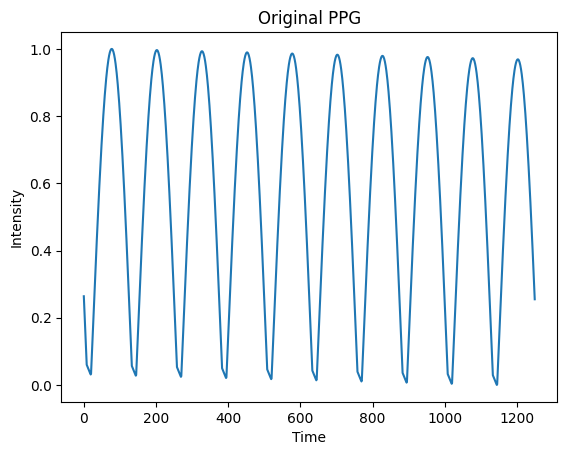

In [2]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=2,
                      basis_type="gaussian")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

Basis 1/2


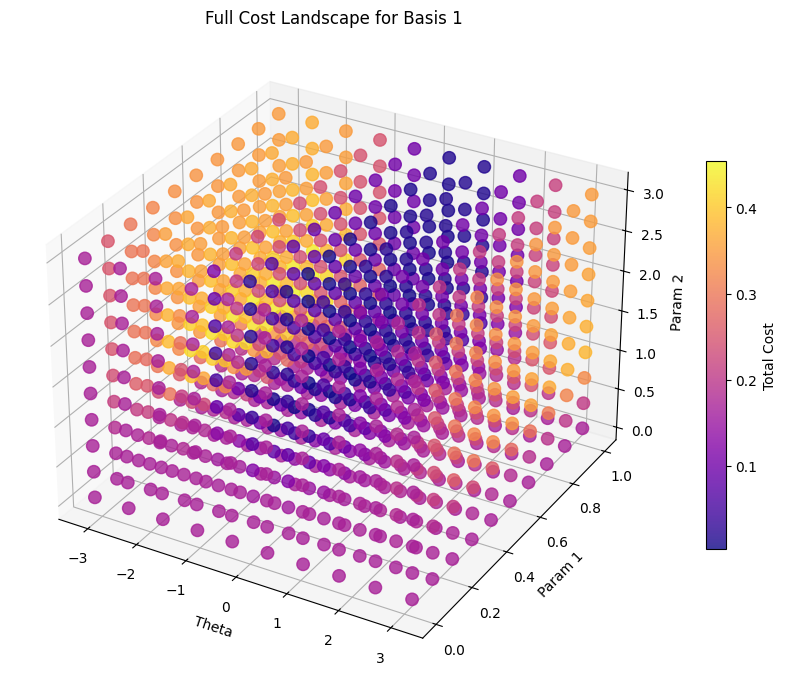

Basis 2/2


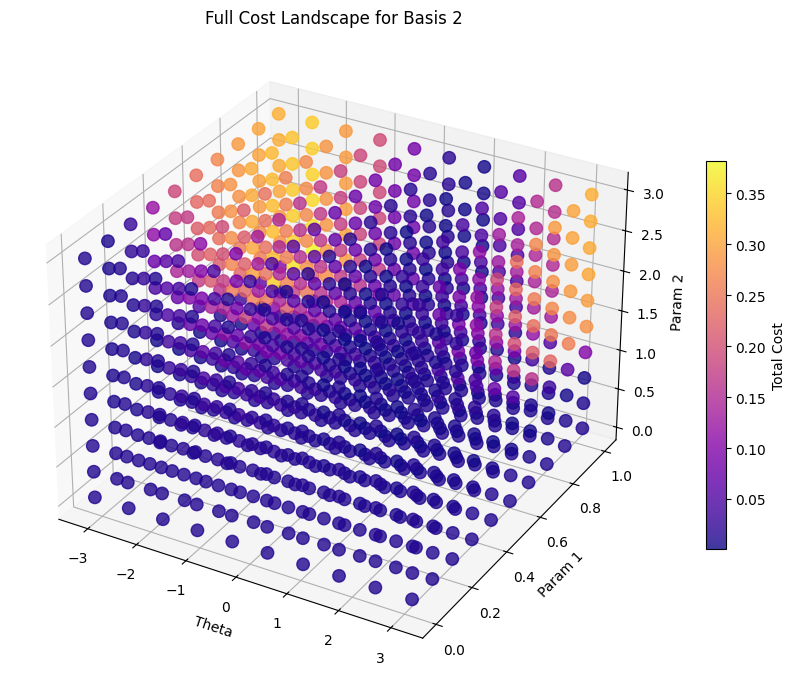

In [3]:
# Extract signal parameters
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=2,
                      basis_type='gaussian')

ppgExt.plot_cost_landscape()

In [4]:
ppgExt.mse_flag = True
ppgExt.corr_flag = True
ppgExt.appg_flag = False
theta_pred, params_pred = ppgExt.extract_ppg(block_update=True, 
                                             coord_cycles=4)

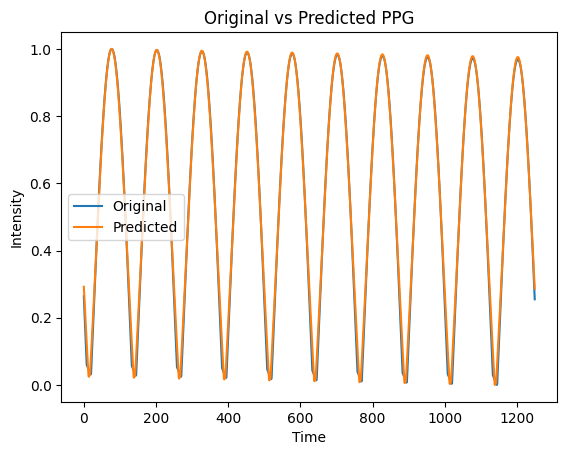

In [5]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=2,
                      basis_type="gaussian",
                      thetas=theta_pred,
                      params=params_pred)
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted"])

In [6]:
# Fig. 4: Show utility in phase extraction and data augmentation
# Later part of paper could argue about augmentated trial datasets, and use for future ML
# Noise resistance models w/ DNNs